# Object Detection Server

This notebook is a short practice guide for running a local FastAPI server that performs object detection with `cvlib`.

## How To Use This Notebook

1. Run the setup cells in order.
2. Start the server.
3. Open `http://127.0.0.1:8000/docs`.
4. Test the `/predict` endpoint with an image from `images/`.

In [1]:
# Create the folders used by the notebook and the API.
import os

os.makedirs("images_with_boxes", exist_ok=True)
os.makedirs("images_uploaded", exist_ok=True)

In [2]:
# Import the libraries required for local image detection.
import cv2

# Reduce TensorFlow log noise while the model loads.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import cvlib as cv
from cvlib.object_detection import draw_bbox
from IPython.display import Image, display


# Run object detection on a local file and save the boxed result.
def detect_and_draw_box(filename, model="yolov3-tiny", confidence=0.5):
    img_filepath = f"images/{filename}"
    img = cv2.imread(img_filepath)

    if img is None:
        raise FileNotFoundError(f"Could not read image: {img_filepath}")

    bbox, label, conf = cv.detect_common_objects(
        img,
        confidence=confidence,
        model=model,
    )

    output_image = draw_bbox(img, bbox, label, conf)
    output_path = f"images_with_boxes/{filename}"
    cv2.imwrite(output_path, output_image)
    display(Image(output_path))

/home/prez/projects/object-detection/.venv/lib/python3.13/site-packages/cvlib/face_detection.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename, Requirement
I0000 00:00:1773154581.120897   19245 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773154582.396141   19245 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Optional Local Check

Run the next cell if you want to verify that the model works before starting the API.

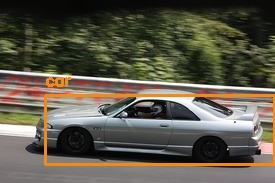

In [3]:
# Try one sample image from the repo before exposing the API.
detect_and_draw_box("car.jpg")

In [4]:
# Import the libraries used by the FastAPI server.
import io
from enum import Enum

import nest_asyncio
import numpy as np
import uvicorn
from fastapi import FastAPI, File, HTTPException, UploadFile
from fastapi.responses import StreamingResponse

In [5]:
# Define the FastAPI application and the object-detection endpoint.
app = FastAPI(title="Object Detection API")


# Restrict the accepted model names to the ones supported by cvlib.
class Model(str, Enum):
    yolov3tiny = "yolov3-tiny"
    yolov3 = "yolov3"


# Provide a simple health message for the root URL.
@app.get("/")
def home():
    return {
        "message": "API is running",
        "docs": "http://127.0.0.1:8000/docs",
    }


# Accept an uploaded image, run detection, and return the boxed image.
@app.post("/predict")
def prediction(model: Model, file: UploadFile = File(...)):
    filename = file.filename or "uploaded-image.jpg"
    file_extension = filename.rsplit(".", 1)[-1].lower() if "." in filename else ""

    if file_extension not in {"jpg", "jpeg", "png"}:
        raise HTTPException(status_code=415, detail="Unsupported file provided.")

    image_stream = io.BytesIO(file.file.read())
    image_stream.seek(0)
    file_bytes = np.asarray(bytearray(image_stream.read()), dtype=np.uint8)
    image = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    if image is None:
        raise HTTPException(status_code=400, detail="The uploaded file is not a valid image.")

    bbox, label, conf = cv.detect_common_objects(image, model=model)
    output_image = draw_bbox(image, bbox, label, conf)

    output_path = f"images_uploaded/{filename}"
    cv2.imwrite(output_path, output_image)

    file_image = open(output_path, mode="rb")
    return StreamingResponse(file_image, media_type="image/jpeg")

In [6]:
# Start Uvicorn inside the notebook event loop.
nest_asyncio.apply()

host = "127.0.0.1"
port = 8000

config = uvicorn.Config(app, host=host, port=port)
server = uvicorn.Server(config)
await server.serve()

INFO:     Started server process [19245]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


INFO:     127.0.0.1:52896 - "POST /predict?model=yolov3-tiny HTTP/1.1" 200 OK
INFO:     127.0.0.1:52912 - "POST /predict?model=yolov3-tiny HTTP/1.1" 200 OK
INFO:     127.0.0.1:52914 - "POST /predict?model=yolov3-tiny HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [19245]


## Test The API

Once the previous cell is running:

1. Open `http://127.0.0.1:8000/docs`.
2. Expand `/predict`.
3. Click **Try it out**.
4. Select `yolov3-tiny`.
5. Upload an image from `images/`.
6. Click **Execute**.